In [1]:
import pandas as pd
import numpy as np
from torchvision import datasets, transforms, models, utils
from torch.utils.data import DataLoader, random_split
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import random

In [3]:
!unzip pizza_steak_sushi.zip

Archive:  pizza_steak_sushi.zip
   creating: test/
   creating: train/
   creating: test/pizza/
   creating: test/steak/
   creating: test/sushi/
  inflating: test/steak/296375.jpg   
  inflating: test/steak/354513.jpg   
  inflating: test/steak/690177.jpg   
  inflating: test/steak/1882831.jpg  
  inflating: test/steak/894825.jpg   
  inflating: test/steak/3424937.jpg  
  inflating: test/steak/2117351.jpg  
  inflating: test/steak/2144308.jpg  
  inflating: test/steak/502076.jpg   
  inflating: test/steak/100274.jpg   
  inflating: test/steak/1285886.jpg  
  inflating: test/steak/1302563.jpg  
  inflating: test/steak/966174.jpg   
  inflating: test/steak/3873283.jpg  
  inflating: test/steak/27415.jpg    
  inflating: test/steak/1868005.jpg  
  inflating: test/steak/1627703.jpg  
  inflating: test/steak/673127.jpg   
  inflating: test/steak/1016217.jpg  
  inflating: test/sushi/479711.jpg   
  inflating: test/sushi/46797.jpg    
  inflating: test/sushi/2521706.jpg  
  inflating: test/

In [4]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load train and test dataset
train_dataset = datasets.ImageFolder(root="/content/train", transform=transform)
test_dataset = datasets.ImageFolder(root="/content/test", transform=transform)

# DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32,
                                          shuffle=False)

class_names = train_dataset.classes
print(f"Classes: {class_names}")
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

Classes: ['pizza', 'steak', 'sushi']
Train size: 225, Test size: 75


**Visualize Data Set**

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


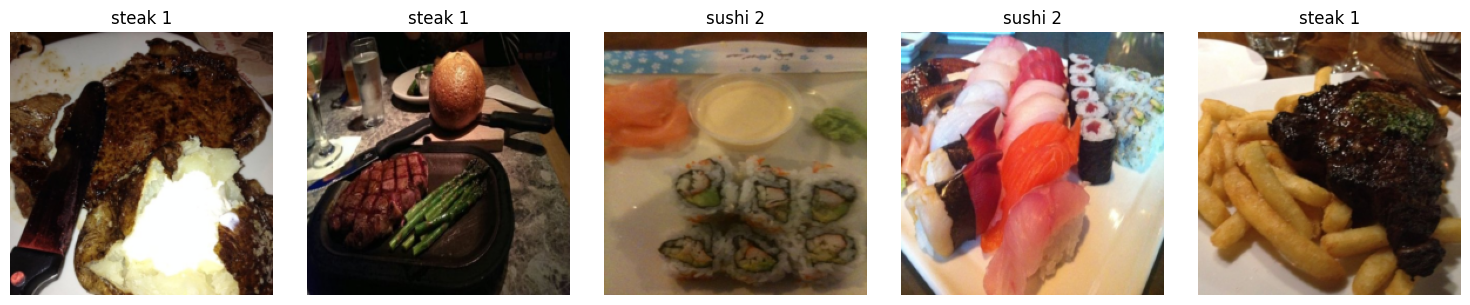

In [5]:
def visualize_sample(dataset, class_name, num_sample=5):
    indices = random.sample(range(len(dataset)), num_sample)
    plt.figure(figsize=(15, 3))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        print(image.size())

        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image = std * image + mean
            image = np.clip(image, 0, 1)

        plt.subplot(1, num_sample, i+1)
        plt.imshow(image)
        plt.title(f"{class_name[label]} {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_sample(dataset=train_dataset, class_name=class_names, num_sample=5)

#Train Using VGG

In [6]:
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 172MB/s]


In [7]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
for param in vgg16.features.parameters():
    param.requires_grad = False

In [9]:
num_features = vgg16.classifier[6].in_features
vgg16.classifier[6] = nn.Linear(num_features, len(class_names))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
vgg16 = vgg16.to(device)

print(vgg16.classifier)

Using device: cuda
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=3, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier[6].parameters(), lr=0.001)

In [11]:
def train_model(model, criterion, optimizer, num_epochs=5):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'Training Loss: {epoch_loss:.4f} | Acc: {100*epoch_acc:.2f}%')

    return model

In [12]:
model_trained = train_model(vgg16, criterion, optimizer, num_epochs=5)

Epoch 1/5
--------------------
Training Loss: 0.7138 | Acc: 67.11%
Epoch 2/5
--------------------
Training Loss: 0.2724 | Acc: 91.56%
Epoch 3/5
--------------------
Training Loss: 0.2135 | Acc: 92.00%
Epoch 4/5
--------------------
Training Loss: 0.1649 | Acc: 94.67%
Epoch 5/5
--------------------
Training Loss: 0.1383 | Acc: 94.22%


In [13]:
model_trained.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_trained(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 86.67%


In [14]:
torch.save(model_trained.state_dict(), 'vgg16_food_class.pth')
print('Model saved as vgg16_food_class.pth')

Model saved as vgg16_food_class.pth


Predicted: pizza, Probability: 0.9994


Text(0.5, 1.0, 'Predicted: pizza | True: pizza')

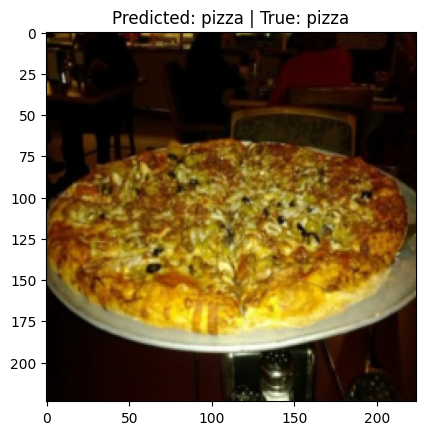

In [15]:
import torch
import torch.nn as nn

# Inference on a single test image
dataiter = iter(test_loader)
images, labels = next(dataiter)
idx = 0
img = images[idx].unsqueeze(0).to(device)  # Add batch dimension for model input
label = labels[idx]

# Forward pass through the network
output = model_trained(img)

# The output is a tensor of raw scores for each class
# Get the predicted class index
_, predicted = torch.max(output, 1)

# Convert the predicted scores to probabilities using softmax
probabilities = nn.Softmax(dim=1)(output)

# Get the predicted class label and its probability
predicted_class_label = class_names[predicted.item()]
predicted_probability = probabilities[0, predicted].item()

# Remove the batch dimension and permute for plotting
img = img.squeeze(0).permute(1, 2, 0).cpu().numpy() # Move to CPU before converting to numpy
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)


# Print the result
print(f"Predicted: {predicted_class_label}, Probability: {predicted_probability:.4f}")
plt.imshow(img)
plt.title(f"Predicted: {class_names[predicted.item()]} | True: {class_names[label.item()]}")

Using ResNet50 for Image Classification

In [16]:
# Load a pre-trained ResNet50 model
resnet50 = models.resnet50(pretrained=True)

# Freeze all parameters in the feature-extracting layers
for param in resnet50.parameters():
    param.requires_grad = False

# Modify the final classification layer to match the number of classes
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_ftrs, len(class_names))

# Move the model to the appropriate device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
resnet50 = resnet50.to(device)

print(resnet50)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Using device: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=

In [17]:
# Define criterion and optimizer for ResNet50
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet50.fc.parameters(), lr=0.001)

In [18]:
# Train the ResNet50 model
model_trained_resnet = train_model(resnet50, criterion_resnet, optimizer_resnet, num_epochs=5)

Epoch 1/5
--------------------
Training Loss: 1.1201 | Acc: 38.67%
Epoch 2/5
--------------------
Training Loss: 0.9433 | Acc: 46.67%
Epoch 3/5
--------------------
Training Loss: 0.8703 | Acc: 61.78%
Epoch 4/5
--------------------
Training Loss: 0.6030 | Acc: 79.56%
Epoch 5/5
--------------------
Training Loss: 0.5695 | Acc: 82.67%


In [19]:
# Evaluate the trained ResNet50 model
model_trained_resnet.eval()
correct_resnet = 0
total_resnet = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_trained_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total_resnet += labels.size(0)
        correct_resnet += (predicted == labels).sum().item()

print(f'ResNet50 Test Accuracy: {100 * correct_resnet / total_resnet:.2f}%')

ResNet50 Test Accuracy: 78.67%


In [20]:
torch.save(model_trained_resnet.state_dict(), 'resnet50_food_class.pth')
print('ResNet50 Model saved as resnet50_food_class.pth')

ResNet50 Model saved as resnet50_food_class.pth


Performance Metrics Comparison: VGG16 vs. ResNet50

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return np.array(all_labels), np.array(all_predictions)

VGG16 Model Metrics

In [22]:
# Get predictions and labels for VGG16
vgg16.eval()
vgg16.load_state_dict(torch.load('vgg16_food_class.pth')) # Load the saved VGG16 model weights
vgg16 = vgg16.to(device) # Ensure model is on the correct device
true_labels_vgg, predictions_vgg = get_predictions_and_labels(vgg16, test_loader, device)

print("VGG16 Classification Report:")
print(classification_report(true_labels_vgg, predictions_vgg, target_names=class_names))

print("VGG16 Confusion Matrix:")
print(confusion_matrix(true_labels_vgg, predictions_vgg))

VGG16 Classification Report:
              precision    recall  f1-score   support

       pizza       0.88      0.88      0.88        25
       steak       0.82      0.95      0.88        19
       sushi       0.89      0.81      0.85        31

    accuracy                           0.87        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.87      0.87      0.87        75

VGG16 Confusion Matrix:
[[22  1  2]
 [ 0 18  1]
 [ 3  3 25]]


ResNet50 Model Metrics

In [23]:
# Get predictions and labels for ResNet50
resnet50.eval()
resnet50.load_state_dict(torch.load('resnet50_food_class.pth')) # Load the saved ResNet50 model weights
resnet50 = resnet50.to(device) # Ensure model is on the correct device
true_labels_resnet, predictions_resnet = get_predictions_and_labels(resnet50, test_loader, device)

print("ResNet50 Classification Report:")
print(classification_report(true_labels_resnet, predictions_resnet, target_names=class_names))

print("ResNet50 Confusion Matrix:")
print(confusion_matrix(true_labels_resnet, predictions_resnet))

ResNet50 Classification Report:
              precision    recall  f1-score   support

       pizza       0.66      0.92      0.77        25
       steak       1.00      0.68      0.81        19
       sushi       0.85      0.74      0.79        31

    accuracy                           0.79        75
   macro avg       0.84      0.78      0.79        75
weighted avg       0.82      0.79      0.79        75

ResNet50 Confusion Matrix:
[[23  0  2]
 [ 4 13  2]
 [ 8  0 23]]


Prepare Data and Retrain Models for Curve Visualization

In [24]:
# Create a validation split from the training dataset
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation

train_dataset_new, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create new DataLoaders for the split datasets
train_loader_new = DataLoader(train_dataset_new, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"New training set size: {len(train_dataset_new)}")
print(f"Validation set size: {len(val_dataset)}")

New training set size: 180
Validation set size: 45


In [25]:
def train_model_with_history(model, criterion, optimizer, train_loader, val_loader, num_epochs=5):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc.item())
        print(f'Training Loss: {epoch_train_loss:.4f} | Acc: {100*epoch_train_acc:.2f}%')

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                running_val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = running_val_corrects.double() / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc.item())
        print(f'Validation Loss: {epoch_val_loss:.4f} | Acc: {100*epoch_val_acc:.2f}%')

    return model, {"train_losses": train_losses, "train_accs": train_accs, "val_losses": val_losses, "val_accs": val_accs}

VGG16 Model Retraining and Curve Visualization

In [26]:
# Re-instantiate VGG16 to ensure a clean state for retraining
vgg16_new = models.vgg16(pretrained=True)

# Freeze feature layers
for param in vgg16_new.features.parameters():
    param.requires_grad = False

# Modify classifier
num_features_vgg_new = vgg16_new.classifier[6].in_features
vgg16_new.classifier[6] = nn.Linear(num_features_vgg_new, len(class_names))
vgg16_new = vgg16_new.to(device)

criterion_vgg_new = nn.CrossEntropyLoss()
optimizer_vgg_new = optim.Adam(vgg16_new.classifier[6].parameters(), lr=0.001)

# Train the new VGG16 model with history tracking
model_trained_vgg_new, history_vgg = train_model_with_history(vgg16_new, criterion_vgg_new, optimizer_vgg_new, train_loader_new, val_loader, num_epochs=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5
--------------------
Training Loss: 0.9322 | Acc: 55.00%
Validation Loss: 0.5303 | Acc: 84.44%
Epoch 2/5
--------------------
Training Loss: 0.3368 | Acc: 91.67%
Validation Loss: 0.4642 | Acc: 80.00%
Epoch 3/5
--------------------
Training Loss: 0.2158 | Acc: 95.56%
Validation Loss: 0.3914 | Acc: 91.11%
Epoch 4/5
--------------------
Training Loss: 0.2000 | Acc: 95.56%
Validation Loss: 0.3268 | Acc: 91.11%
Epoch 5/5
--------------------
Training Loss: 0.1342 | Acc: 96.67%
Validation Loss: 0.3132 | Acc: 93.33%


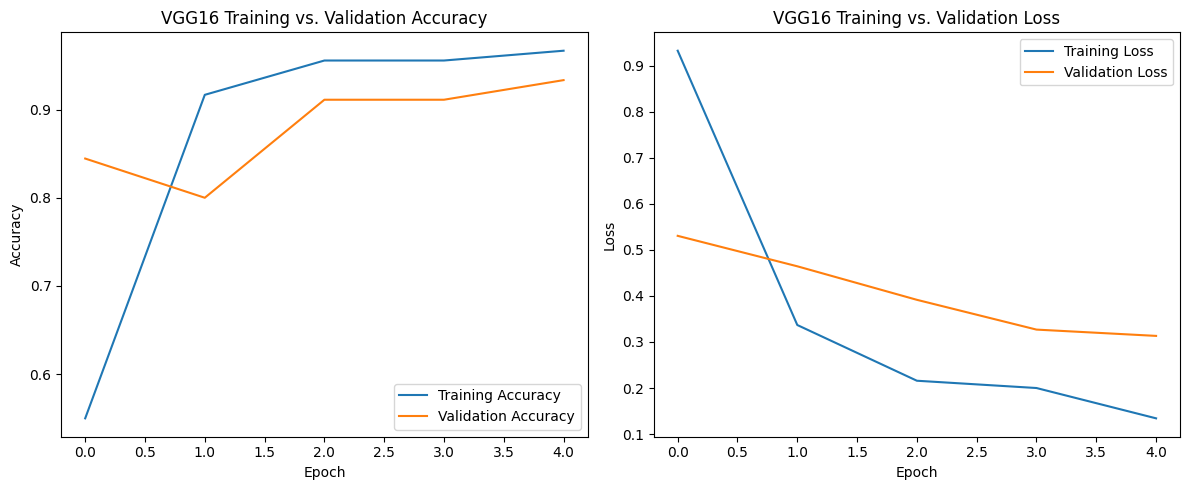

In [27]:
# Plot Training vs. Validation Accuracy and Loss for VGG16
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg['train_accs'], label='Training Accuracy')
plt.plot(history_vgg['val_accs'], label='Validation Accuracy')
plt.title('VGG16 Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg['train_losses'], label='Training Loss')
plt.plot(history_vgg['val_losses'], label='Validation Loss')
plt.title('VGG16 Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

ResNet50 Model Retraining and Curve Visualization

In [28]:
# Re-instantiate ResNet50 to ensure a clean state for retraining
resnet50_new = models.resnet50(pretrained=True)

# Freeze feature layers
for param in resnet50_new.parameters():
    param.requires_grad = False

# Modify classifier
num_ftrs_resnet_new = resnet50_new.fc.in_features
resnet50_new.fc = nn.Linear(num_ftrs_resnet_new, len(class_names))
resnet50_new = resnet50_new.to(device)

criterion_resnet_new = nn.CrossEntropyLoss()
optimizer_resnet_new = optim.Adam(resnet50_new.fc.parameters(), lr=0.001)

# Train the new ResNet50 model with history tracking
model_trained_resnet_new, history_resnet = train_model_with_history(resnet50_new, criterion_resnet_new, optimizer_resnet_new, train_loader_new, val_loader, num_epochs=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5
--------------------
Training Loss: 1.1011 | Acc: 40.00%
Validation Loss: 0.8511 | Acc: 64.44%
Epoch 2/5
--------------------
Training Loss: 0.8659 | Acc: 62.22%
Validation Loss: 0.7022 | Acc: 86.67%
Epoch 3/5
--------------------
Training Loss: 0.6809 | Acc: 79.44%
Validation Loss: 0.6273 | Acc: 88.89%
Epoch 4/5
--------------------
Training Loss: 0.5661 | Acc: 81.11%
Validation Loss: 0.6363 | Acc: 66.67%
Epoch 5/5
--------------------
Training Loss: 0.4587 | Acc: 90.56%
Validation Loss: 0.5723 | Acc: 82.22%


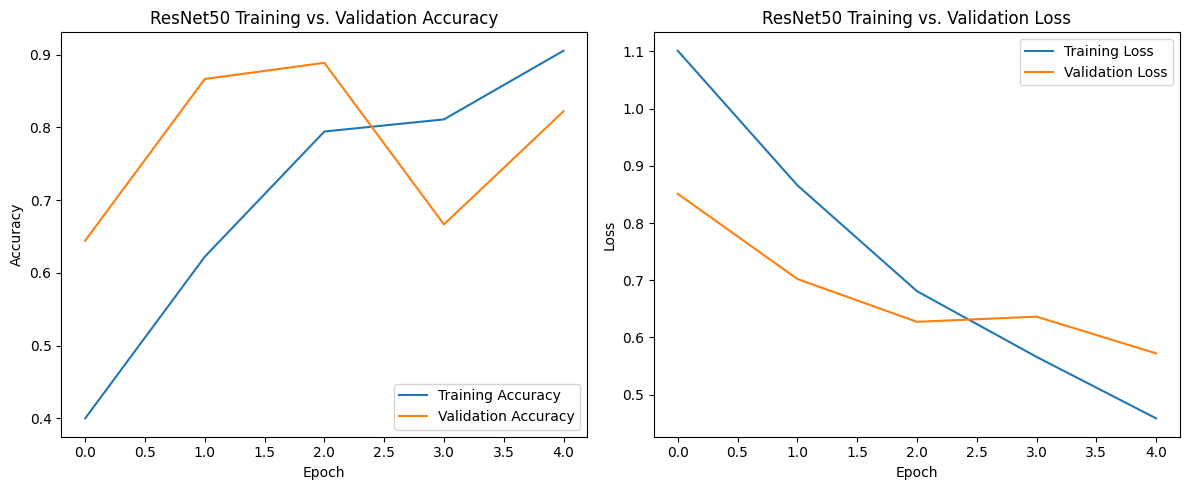

In [29]:
# Plot Training vs. Validation Accuracy and Loss for ResNet50
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet['train_accs'], label='Training Accuracy')
plt.plot(history_resnet['val_accs'], label='Validation Accuracy')
plt.title('ResNet50 Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet['train_losses'], label='Training Loss')
plt.plot(history_resnet['val_losses'], label='Validation Loss')
plt.title('ResNet50 Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Visualize Misclassified Examples

In [30]:
import math

def visualize_misclassified_images(model, dataloader, device, class_names, num_images=5):
    model.eval()
    misclassified_images = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    true_labels.append(labels[i].cpu().item())
                    predicted_labels.append(preds[i].cpu().item())

    if len(misclassified_images) == 0:
        print("No misclassified images found.")
        return

    # Select a random subset of misclassified images if there are more than num_images
    if len(misclassified_images) > num_images:
        indices = random.sample(range(len(misclassified_images)), num_images)
        selected_images = [misclassified_images[i] for i in indices]
        selected_true = [true_labels[i] for i in indices]
        selected_predicted = [predicted_labels[i] for i in indices]
    else:
        selected_images = misclassified_images
        selected_true = true_labels
        selected_predicted = predicted_labels

    plt.figure(figsize=(15, 5))
    for i in range(len(selected_images)):
        img = selected_images[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f'True: {class_names[selected_true[i]]}\nPred: {class_names[selected_predicted[i]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Misclassified examples for VGG16:


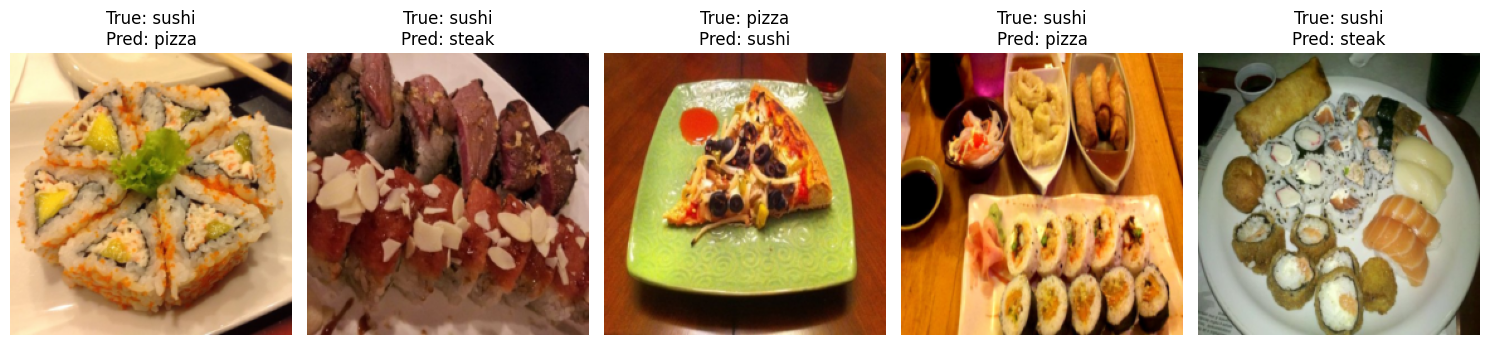

In [31]:
print("Misclassified examples for VGG16:")
visualize_misclassified_images(model_trained_vgg_new, test_loader, device, class_names, num_images=5)

Misclassified examples for ResNet50:


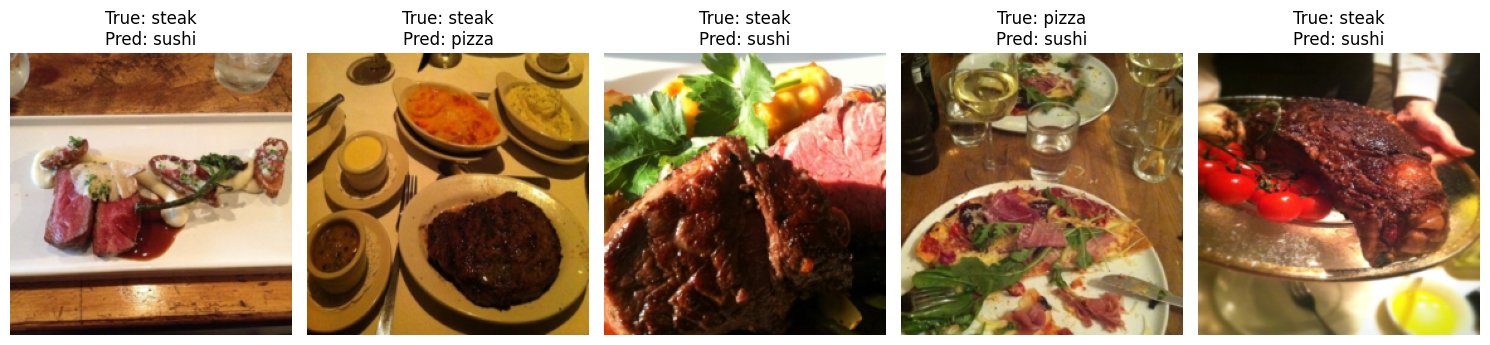

In [32]:
print("Misclassified examples for ResNet50:")
visualize_misclassified_images(model_trained_resnet_new, test_loader, device, class_names, num_images=5)

Fine-tuning VGG16 Model

In [33]:
# Re-instantiate VGG16 model with pre-trained weights
vgg16_finetune = models.vgg16(pretrained=True)

# Unfreeze all parameters initially, then selectively freeze
for param in vgg16_finetune.parameters():
    param.requires_grad = True

# Freeze the first few blocks and unfreeze the last convolutional blocks (e.g., layers from index 24 onwards in features)
# VGG16 features has 31 layers. Layers from 0 to 23 are the first three blocks (64, 128, 256 filters)
# Layers from 24 to 30 are the last two blocks (512 filters) + MaxPool.
# We will unfreeze starting from index 24 (the beginning of the 4th block).
for i, param in enumerate(vgg16_finetune.features.parameters()):
    if i < 24: # Freeze the first 24 parameters (approximately the first 3 convolutional blocks)
        param.requires_grad = False

# Ensure the classifier layers are trainable (they already are by default if we unfreeze all and then selectively freeze)
# But explicitly setting it ensures clarity and prevents accidental freezing if the logic changed.
for param in vgg16_finetune.classifier.parameters():
    param.requires_grad = True

# Replace the classifier head for our specific number of classes (if not already done)
num_features_vgg_finetune = vgg16_finetune.classifier[6].in_features
vgg16_finetune.classifier[6] = nn.Linear(num_features_vgg_finetune, len(class_names))

vgg16_finetune = vgg16_finetune.to(device)

# Define criterion and optimizer for fine-tuning with a lower learning rate
criterion_vgg_finetune = nn.CrossEntropyLoss()
optimizer_vgg_finetune = optim.Adam(vgg16_finetune.parameters(), lr=0.0001) # Lower learning rate for fine-tuning

print("VGG16 Model for fine-tuning structure:")
print(vgg16_finetune)

VGG16 Model for fine-tuning structure:
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_

In [34]:
# Train the fine-tuned VGG16 model
print("Starting VGG16 Fine-tuning...")
model_trained_vgg_finetune, history_vgg_finetune = train_model_with_history(vgg16_finetune, criterion_vgg_finetune, optimizer_vgg_finetune, train_loader_new, val_loader, num_epochs=5)

Starting VGG16 Fine-tuning...
Epoch 1/5
--------------------
Training Loss: 0.8072 | Acc: 62.22%
Validation Loss: 0.4243 | Acc: 88.89%
Epoch 2/5
--------------------
Training Loss: 0.1414 | Acc: 95.56%
Validation Loss: 0.3074 | Acc: 91.11%
Epoch 3/5
--------------------
Training Loss: 0.0356 | Acc: 98.89%
Validation Loss: 0.2468 | Acc: 91.11%
Epoch 4/5
--------------------
Training Loss: 0.0060 | Acc: 100.00%
Validation Loss: 0.2825 | Acc: 88.89%
Epoch 5/5
--------------------
Training Loss: 0.0027 | Acc: 100.00%
Validation Loss: 0.3736 | Acc: 91.11%


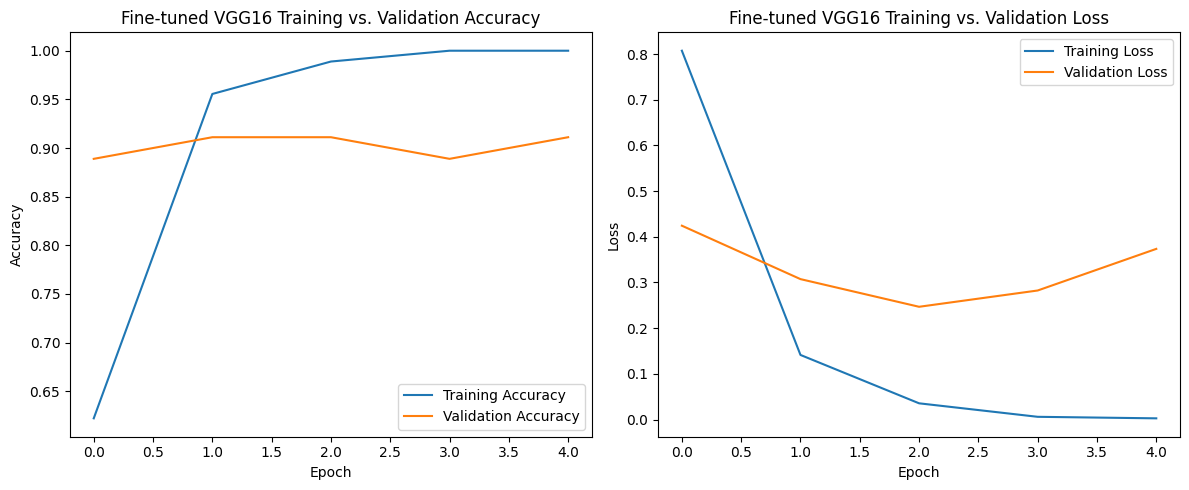

In [35]:
# Plot Training vs. Validation Accuracy and Loss for Fine-tuned VGG16
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg_finetune['train_accs'], label='Training Accuracy')
plt.plot(history_vgg_finetune['val_accs'], label='Validation Accuracy')
plt.title('Fine-tuned VGG16 Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg_finetune['train_losses'], label='Training Loss')
plt.plot(history_vgg_finetune['val_losses'], label='Validation Loss')
plt.title('Fine-tuned VGG16 Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Evaluate the fine-tuned VGG16 model
model_trained_vgg_finetune.eval()
correct_vgg_finetune = 0
total_vgg_finetune = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_trained_vgg_finetune(images)
        _, predicted = torch.max(outputs.data, 1)
        total_vgg_finetune += labels.size(0)
        correct_vgg_finetune += (predicted == labels).sum().item()

print(f'Fine-tuned VGG16 Test Accuracy: {100 * correct_vgg_finetune / total_vgg_finetune:.2f}%')

Fine-tuned VGG16 Test Accuracy: 88.00%


In [37]:
torch.save(model_trained_vgg_finetune.state_dict(), 'vgg16_food_class_finetune.pth')
print('Fine-tuned VGG16 Model saved as vgg16_food_class_finetune.pth')

Fine-tuned VGG16 Model saved as vgg16_food_class_finetune.pth


Fine-tuning ResNet50 Model

In [38]:
# Re-instantiate ResNet50 model with pre-trained weights
resnet50_finetune = models.resnet50(pretrained=True)

# Unfreeze all parameters initially
for param in resnet50_finetune.parameters():
    param.requires_grad = True

# Freeze the initial layers (conv1, bn1, layer1, layer2)
# ResNet50 has layers: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc
for name, param in resnet50_finetune.named_parameters():
    if "layer1" in name or "layer2" in name or "conv1" in name or "bn1" in name or "maxpool" in name:
        param.requires_grad = False

# Ensure the final classification layer is correctly set and trainable
num_ftrs_resnet_finetune = resnet50_finetune.fc.in_features
resnet50_finetune.fc = nn.Linear(num_ftrs_resnet_finetune, len(class_names))

resnet50_finetune = resnet50_finetune.to(device)

# Define criterion and optimizer for fine-tuning with a lower learning rate
criterion_resnet_finetune = nn.CrossEntropyLoss()
optimizer_resnet_finetune = optim.Adam(resnet50_finetune.parameters(), lr=0.0001) # Lower learning rate for fine-tuning

print("ResNet50 Model for fine-tuning structure:")
print(resnet50_finetune)

ResNet50 Model for fine-tuning structure:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2

In [39]:
# Train the fine-tuned ResNet50 model
print("Starting ResNet50 Fine-tuning...")
model_trained_resnet_finetune, history_resnet_finetune = train_model_with_history(resnet50_finetune, criterion_resnet_finetune, optimizer_resnet_finetune, train_loader_new, val_loader, num_epochs=5)

Starting ResNet50 Fine-tuning...
Epoch 1/5
--------------------
Training Loss: 0.8934 | Acc: 59.44%
Validation Loss: 0.5533 | Acc: 84.44%
Epoch 2/5
--------------------
Training Loss: 0.2222 | Acc: 98.89%
Validation Loss: 0.3387 | Acc: 88.89%
Epoch 3/5
--------------------
Training Loss: 0.0749 | Acc: 100.00%
Validation Loss: 0.2994 | Acc: 88.89%
Epoch 4/5
--------------------
Training Loss: 0.0123 | Acc: 100.00%
Validation Loss: 0.2899 | Acc: 91.11%
Epoch 5/5
--------------------
Training Loss: 0.0096 | Acc: 100.00%
Validation Loss: 0.2872 | Acc: 86.67%


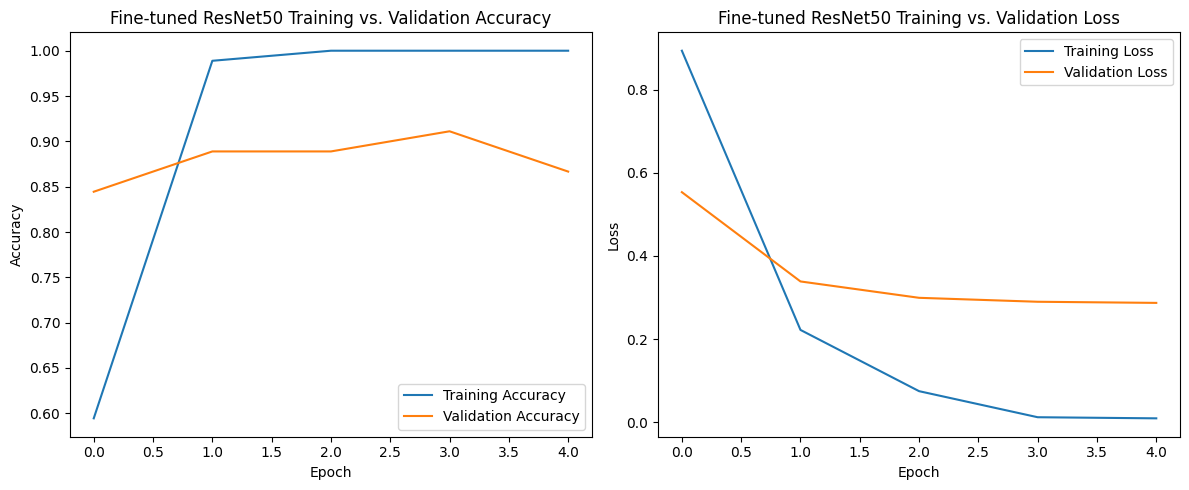

In [40]:
# Plot Training vs. Validation Accuracy and Loss for Fine-tuned ResNet50
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet_finetune['train_accs'], label='Training Accuracy')
plt.plot(history_resnet_finetune['val_accs'], label='Validation Accuracy')
plt.title('Fine-tuned ResNet50 Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet_finetune['train_losses'], label='Training Loss')
plt.plot(history_resnet_finetune['val_losses'], label='Validation Loss')
plt.title('Fine-tuned ResNet50 Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Evaluate the fine-tuned ResNet50 model
model_trained_resnet_finetune.eval()
correct_resnet_finetune = 0
total_resnet_finetune = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_trained_resnet_finetune(images)
        _, predicted = torch.max(outputs.data, 1)
        total_resnet_finetune += labels.size(0)
        correct_resnet_finetune += (predicted == labels).sum().item()

print(f'Fine-tuned ResNet50 Test Accuracy: {100 * correct_resnet_finetune / total_resnet_finetune:.2f}%')

Fine-tuned ResNet50 Test Accuracy: 96.00%


In [42]:
torch.save(model_trained_resnet_finetune.state_dict(), 'resnet50_food_class_finetune.pth')
print('Fine-tuned ResNet50 Model saved as resnet50_food_class_finetune.pth')

Fine-tuned ResNet50 Model saved as resnet50_food_class_finetune.pth
